# Fraud Detection Analysis

This project simulates fraud detection in transactional data.

## Contents:
- Data generation
- Exploratory analysis
- Feature engineering
- Modeling
- Business evaluation

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

In [2]:
# 1. PARÁMETROS
# -----------------------------
N_USERS = 1000
N_TRANSACTIONS = 50000
FRAUD_RATE = 0.02


In [3]:
# 2. GENERAR USUARIOS
# -----------------------------
users = pd.DataFrame({
    "user_id": np.arange(1, N_USERS + 1),
    "pais": np.random.choice(["AR", "BR", "MX"], N_USERS, p=[0.6, 0.2, 0.2]),
    "edad_cuenta_dias": np.random.randint(10, 1000, N_USERS),
    "promedio_monto": np.random.uniform(1000, 20000, N_USERS),
    "frecuencia_compra": np.random.uniform(0.5, 3, N_USERS)
})

In [4]:
# 3. GENERAR TRANSACCIONES
# -----------------------------
transactions = pd.DataFrame({
    "transaction_id": np.arange(1, N_TRANSACTIONS + 1),
    "user_id": np.random.choice(users["user_id"], N_TRANSACTIONS),
    "timestamp": pd.to_datetime("2025-01-01") + pd.to_timedelta(
        np.random.randint(0, 60*60*24*30, N_TRANSACTIONS), unit="s"
    ),
    "device": np.random.choice(["mobile", "desktop"], N_TRANSACTIONS, p=[0.7, 0.3])
})

In [5]:
# Merge con info de usuarios
transactions = transactions.merge(users, on="user_id", how="left")

# Generar monto basado en el promedio del usuario
transactions["monto"] = np.random.normal(
    transactions["promedio_monto"],
    transactions["promedio_monto"] * 0.3
)

transactions["monto"] = transactions["monto"].clip(100, None)

print(transactions.head())
print(transactions.columns)

   transaction_id  user_id           timestamp   device pais  \
0               1      802 2025-01-02 22:05:57  desktop   AR   
1               2      763 2025-01-06 13:22:30  desktop   AR   
2               3      276 2025-01-13 20:48:09   mobile   AR   
3               4       50 2025-01-10 02:32:30   mobile   AR   
4               5      358 2025-01-11 16:27:33   mobile   AR   

   edad_cuenta_dias  promedio_monto  frecuencia_compra         monto  
0                29    14566.620245           0.666158  16711.056701  
1               871     9977.373745           2.637435   8516.375832  
2               982     2611.048305           1.983902   3998.391786  
3               603     9583.585896           2.823070  11555.713348  
4               873    10658.850391           1.011700  11296.875251  
Index(['transaction_id', 'user_id', 'timestamp', 'device', 'pais',
       'edad_cuenta_dias', 'promedio_monto', 'frecuencia_compra', 'monto'],
      dtype='str')


In [6]:
# País igual al del usuario (normal)
transactions["pais_tx"] = transactions["pais"]

In [7]:
# Inicialmente todo no fraude
transactions["es_fraude"] = 0

In [8]:
# 4. INYECTAR FRAUDE
# -----------------------------
n_fraud = int(N_TRANSACTIONS * FRAUD_RATE)
fraud_idx = np.random.choice(transactions.index, n_fraud, replace=False)

In [9]:
# Caso 1: monto muy alto
transactions.loc[fraud_idx[:int(n_fraud*0.4)], "monto"] *= 5

In [10]:
# Caso 2: cambio de país
transactions.loc[fraud_idx[int(n_fraud*0.4):int(n_fraud*0.7)], "pais_tx"] = np.random.choice(["US", "CN", "IN"])

In [11]:
# Caso 3: cuenta nueva + monto alto
new_account_idx = fraud_idx[int(n_fraud*0.7):]
transactions.loc[new_account_idx, "edad_cuenta_dias"] = np.random.randint(1, 5, len(new_account_idx))
transactions.loc[new_account_idx, "monto"] *= 4

In [12]:
# Marcar fraude
transactions.loc[fraud_idx, "es_fraude"] = 1

In [13]:
transactions.groupby("es_fraude")["monto"].mean()

es_fraude
0    10474.052844
1    37087.322199
Name: monto, dtype: float64

In [14]:
transactions.groupby("es_fraude")["edad_cuenta_dias"].mean()

es_fraude
0    513.713939
1    360.470000
Name: edad_cuenta_dias, dtype: float64

In [15]:
transactions["pais_tx"].value_counts()

pais_tx
AR    30459
MX     9928
BR     9313
CN      300
Name: count, dtype: int64

In [16]:
# 1. KPIs DE FRAUDE

# Tasa de fraude total
fraud_rate = transactions["es_fraude"].mean()

# Promedio de monto en fraude vs no fraude
avg_monto_fraud = transactions[transactions["es_fraude"] == 1]["monto"].mean()
avg_monto_legit = transactions[transactions["es_fraude"] == 0]["monto"].mean()

# Pérdida total estimada por fraude
fraud_loss = transactions.loc[transactions["es_fraude"] == 1, "monto"].sum()

print("Fraud rate:", fraud_rate)
print("Avg monto (fraude):", avg_monto_fraud)
print("Avg monto (no fraude):", avg_monto_legit)
print("Pérdida total por fraude:", fraud_loss)

Fraud rate: 0.02
Avg monto (fraude): 37087.322199225084
Avg monto (no fraude): 10474.05284402831
Pérdida total por fraude: 37087322.19922508


In [17]:
# 2. ANÁLISIS DE PATRONES

# Tasa de fraude por país de la transacción
fraud_by_country = transactions.groupby("pais_tx")["es_fraude"].mean()

# Tasa de fraude por tipo de dispositivo
fraud_by_device = transactions.groupby("device")["es_fraude"].mean()

# Crear variable de monto alto
transactions["high_monto"] = transactions["monto"] > 10000

# Tasa de fraude según monto alto
fraud_by_monto = transactions.groupby("high_monto")["es_fraude"].mean()

print("\nFraude por país:\n", fraud_by_country)
print("\nFraude por dispositivo:\n", fraud_by_device)
print("\nFraude por monto alto:\n", fraud_by_monto)


Fraude por país:
 pais_tx
AR    0.013526
BR    0.013422
CN    1.000000
MX    0.016418
Name: es_fraude, dtype: float64

Fraude por dispositivo:
 device
desktop    0.020197
mobile     0.019915
Name: es_fraude, dtype: float64

Fraude por monto alto:
 high_monto
False    0.008297
True     0.032348
Name: es_fraude, dtype: float64


In [18]:
print(transactions.columns)

Index(['transaction_id', 'user_id', 'timestamp', 'device', 'pais',
       'edad_cuenta_dias', 'promedio_monto', 'frecuencia_compra', 'monto',
       'pais_tx', 'es_fraude', 'high_monto'],
      dtype='str')


In [19]:
# 3. FEATURE ENGINEERING (SEÑALES DE RIESGO)

# Ratio entre monto de la transacción y el promedio del usuario
transactions["ratio_monto"] = transactions["monto"] / transactions["promedio_monto"]

# Flag de cuenta nueva (menos de 7 días)
transactions["cuenta_nueva"] = transactions["edad_cuenta_dias"] < 7

# Inconsistencia de país (usuario vs transacción)
transactions["pais_diff"] = transactions["pais"] != transactions["pais_tx"]

In [20]:
# 4. MODELO SIMPLE (REGRESIÓN LOGÍSTICA)
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Selección de features
features = ["ratio_monto", "cuenta_nueva", "pais_diff"]

X = transactions[features]
y = transactions["es_fraude"]

In [21]:
# División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamiento del modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluación
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))



Reporte de clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9799
           1       1.00      0.97      0.98       201

    accuracy                           1.00     10000
   macro avg       1.00      0.98      0.99     10000
weighted avg       1.00      1.00      1.00     10000



In [22]:
# 5. SCORE Y DECISIÓN DE NEGOCIO
# =====================================================

# Probabilidad de fraude (score)
transactions["score"] = model.predict_proba(X)[:, 1]

# Definir umbral de decisión (ajustable)
threshold = 0.7

# Flag de transacciones sospechosas
transactions["flag"] = transactions["score"] > threshold


In [23]:
#Evaluación de impacto

# Fraudes detectados correctamente
fraud_detected = transactions[
    (transactions["es_fraude"] == 1) & (transactions["flag"] == True)
].shape[0]

# Falsos positivos (usuarios legítimos bloqueados)
false_positives = transactions[
    (transactions["es_fraude"] == 0) & (transactions["flag"] == True)
].shape[0]

print("\nFraudes detectados:", fraud_detected)
print("Falsos positivos:", false_positives)


Fraudes detectados: 963
Falsos positivos: 0


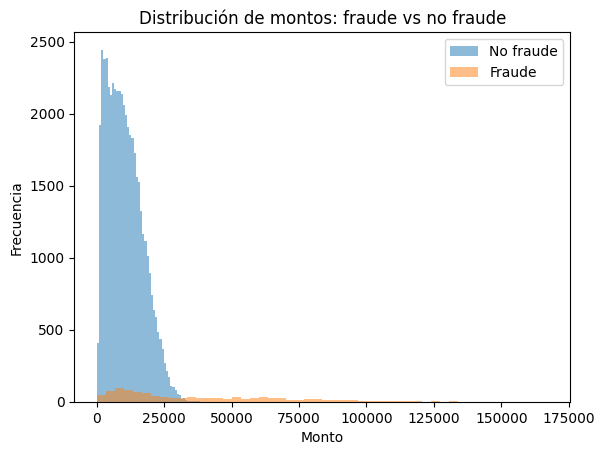

In [27]:
import matplotlib.pyplot as plt

# Separar datos
fraud = transactions[transactions["es_fraude"] == 1]
legit = transactions[transactions["es_fraude"] == 0]

plt.figure()

plt.hist(legit["monto"], bins=50, alpha=0.5, label="No fraude")
plt.hist(fraud["monto"], bins=50, alpha=0.5, label="Fraude")

plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.title("Distribución de montos: fraude vs no fraude")
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

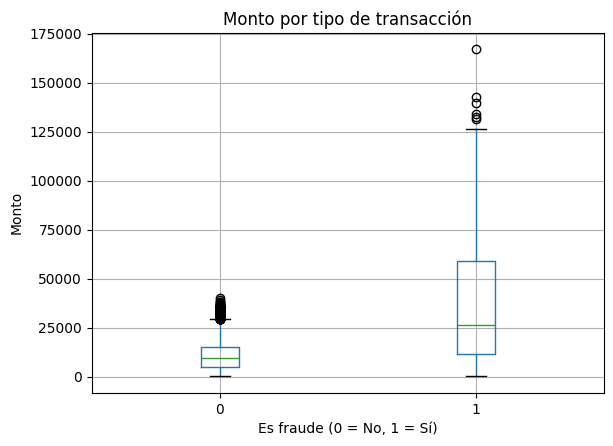

In [28]:
plt.figure()

transactions.boxplot(column="monto", by="es_fraude")

plt.title("Monto por tipo de transacción")
plt.suptitle("")  # limpia título automático
plt.xlabel("Es fraude (0 = No, 1 = Sí)")
plt.ylabel("Monto")

plt.show()

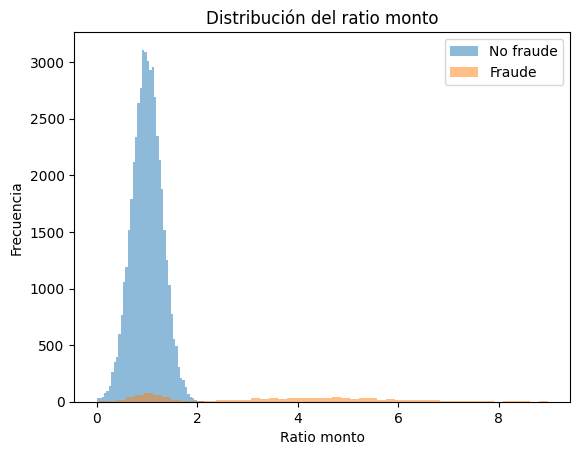

In [29]:
plt.figure()

plt.hist(transactions[transactions["es_fraude"] == 0]["ratio_monto"], bins=50, alpha=0.5, label="No fraude")
plt.hist(transactions[transactions["es_fraude"] == 1]["ratio_monto"], bins=50, alpha=0.5, label="Fraude")

plt.xlabel("Ratio monto")
plt.ylabel("Frecuencia")
plt.title("Distribución del ratio monto")
plt.legend()

plt.show()